# CSC 591: Project 3

**Dataset:** Daily weather observations - Raleigh-Durham International Airport  
**Source:** NOAA, 2022–2026  
**Samples:** 1,477 clean rows

| Variable | Description | Unit | Role |
|----------|-------------|------|------|
| X1 | TMAX — Max daily temperature | °F | Input |
| X2 | TMIN — Min daily temperature | °F | Input |
| X3 | PRCP — Daily precipitation | inches | Input |
| X4 | AWND — Avg wind speed | mph | Input |
| X5 | SNOW — Daily snowfall | inches | Input |
| Y  | TAVG — Avg daily temperature | °F | **Output** |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import probplot
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False
})

df_raw = pd.read_csv('weather_clean.csv')
print(f'Loaded: {df_raw.shape[0]} rows, columns: {list(df_raw.columns)}')
df_raw.describe().round(3)

Loaded: 1477 rows, columns: ['X1', 'X2', 'X3', 'X4', 'X5', 'Y']


,X1,X2,X3,X4,X5,Y
count,1477.000,1477.000,1477.000,1477.000,1477.000,1477.000
mean,73.823,52.228,0.125,5.896,0.006,62.602
std,15.508,15.874,0.364,2.886,0.088,14.998
min,29.000,10.000,0.000,0.450,0.000,19.000
25%,63.000,39.000,0.000,3.800,0.000,51.000
50%,75.000,54.000,0.000,5.370,0.000,65.000
75%,86.000,66.000,0.030,7.610,0.000,75.000
max,106.000,80.000,4.020,19.910,2.300,89.000


## Task 1 - Basic Statistical Analysis

### Task 1.1

Variable       Mean     Variance    Std Dev
──────────────────────────────────────────
X1        73.8226     240.4875    15.5077
X2        52.2282     251.9865    15.8741
X3         0.1254       0.1327     0.3642
X4         5.8956       8.3307     2.8863
X5         0.0056       0.0078     0.0882


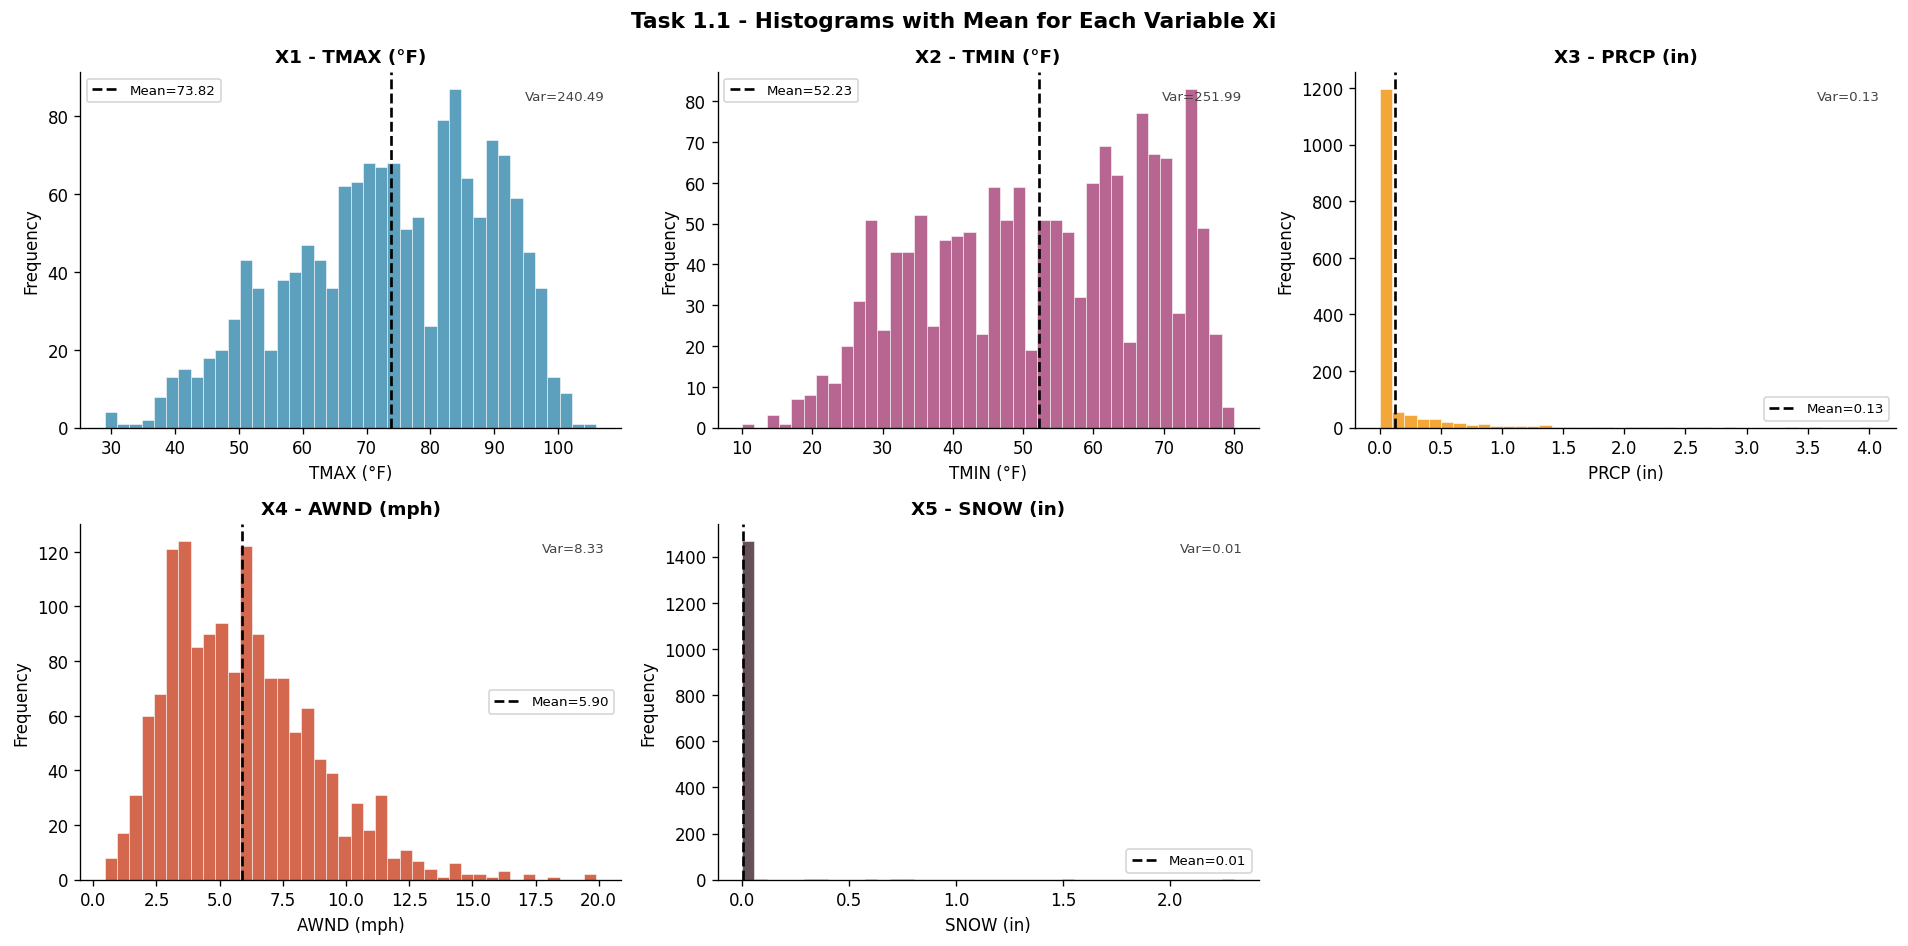

In [2]:
variables = ['X1','X2','X3','X4','X5']
colors    = ['#2E86AB','#A23B72','#F18F01','#C73E1D','#3B1F2B']
labels    = {
    'X1':'TMAX (°F)', 'X2':'TMIN (°F)',
    'X3':'PRCP (in)', 'X4':'AWND (mph)', 'X5':'SNOW (in)'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

print(f"{'Variable':<6} {'Mean':>10} {'Variance':>12} {'Std Dev':>10}")
print('─'*42)
for i, col in enumerate(variables):
    mean = df_raw[col].mean()
    var  = df_raw[col].var()
    std  = df_raw[col].std()
    print(f"{col:<6} {mean:>10.4f} {var:>12.4f} {std:>10.4f}")

    axes[i].hist(df_raw[col], bins=40, color=colors[i], alpha=0.78,
                 edgecolor='white', linewidth=0.4)
    axes[i].axvline(mean, color='black', linestyle='--',
                    linewidth=1.6, label=f'Mean={mean:.2f}')
    axes[i].set_title(f'{col} - {labels[col]}', fontweight='bold')
    axes[i].set_xlabel(labels[col])
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)
    axes[i].text(0.97, 0.95, f'Var={var:.2f}',
                 transform=axes[i].transAxes, fontsize=8,
                 ha='right', va='top', color='#444')

axes[5].set_visible(False)
fig.suptitle('Task 1.1 - Histograms with Mean for Each Variable Xi',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('t1_histograms.png', dpi=150, bbox_inches='tight')
plt.show()


### Task 1.2 

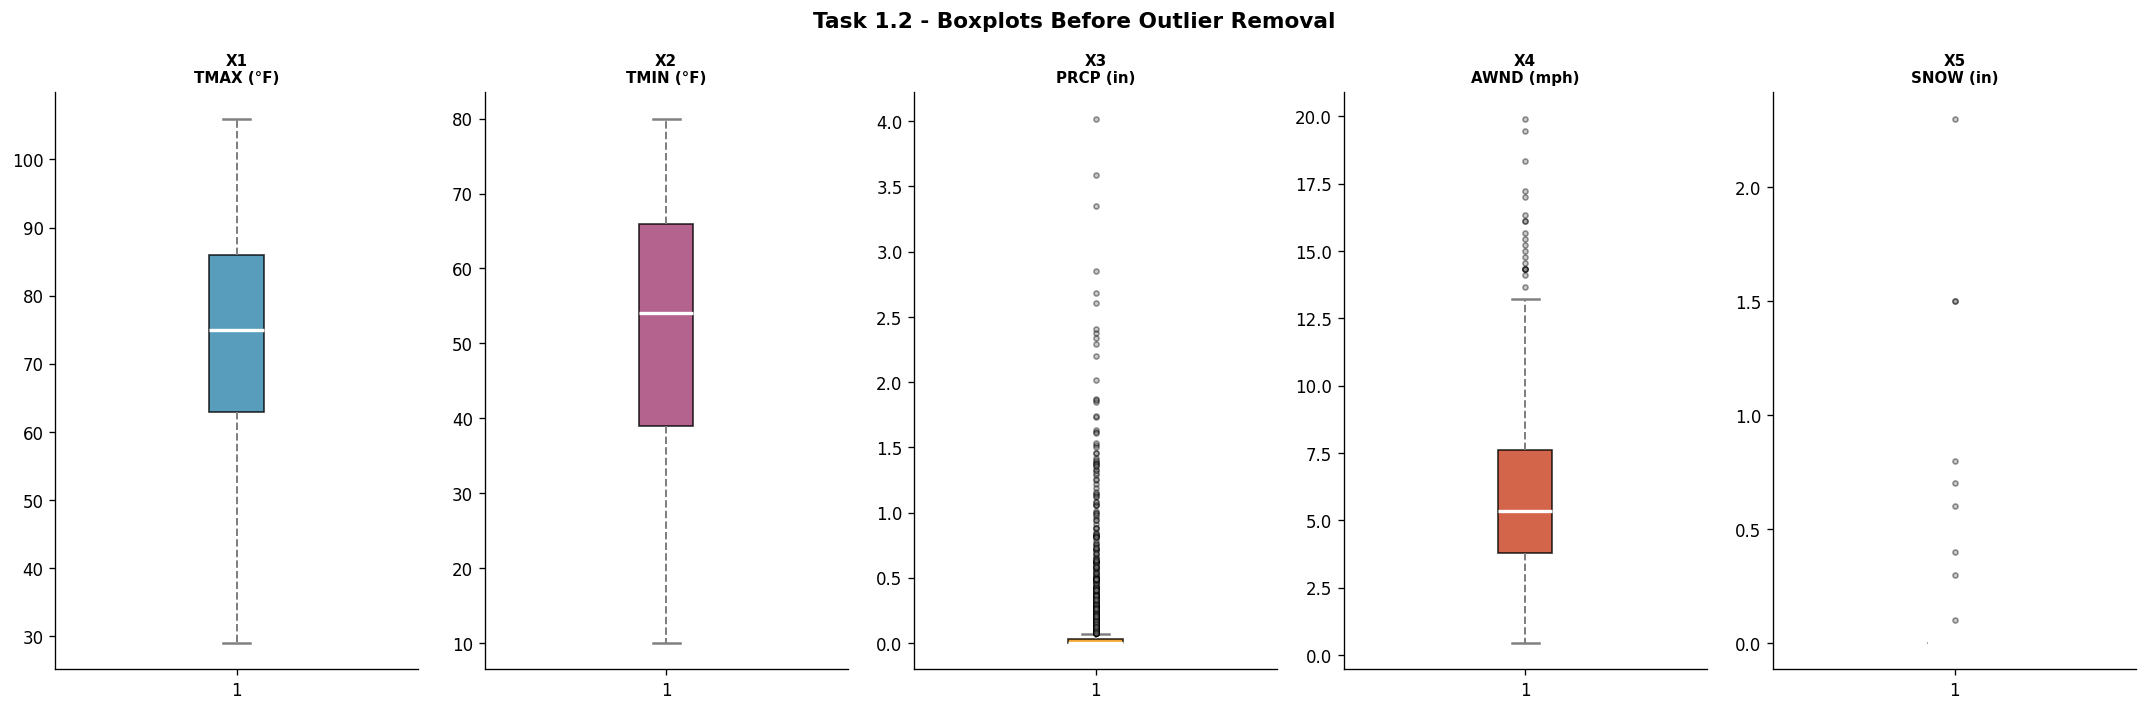

Outlier removal log:
Variable Method                          Removed  Remaining
────────────────────────────────────────────────────────────
X3       99th pct cap (<= 1.766)              15       1462
X4       3x IQR cap (<= 19.04)                 1       1461
X5       NOT cleaned                           0       1461

Final dataset: 1461 rows (98.9% retained)
X5 non-zero values remaining: 9
X5 variance: 0.007873  - still has variance, usable for correlation


In [3]:
fig, axes = plt.subplots(1, 5, figsize=(18, 6))
for i, col in enumerate(variables):
    bp = axes[i].boxplot(df_raw[col], patch_artist=True,
        medianprops  = dict(color='white', linewidth=2),
        whiskerprops = dict(color='gray', linewidth=1.2, linestyle='--'),
        capprops     = dict(color='gray', linewidth=1.5),
        flierprops   = dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.4))
    bp['boxes'][0].set_facecolor(colors[i])
    bp['boxes'][0].set_alpha(0.8)
    axes[i].set_title(f'{col}\n{labels[col]}', fontweight='bold', fontsize=9)
fig.suptitle('Task 1.2 - Boxplots Before Outlier Removal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('t1_boxplots_before.png', dpi=150, bbox_inches='tight')
plt.show()

df_clean = df_raw.copy()
print('Outlier removal log:')
print(f"{'Variable':<8} {'Method':<30} {'Removed':>8} {'Remaining':>10}")
print('─'*60)

p99 = df_clean['X3'].quantile(0.99)
before = len(df_clean)
df_clean = df_clean[df_clean['X3'] <= p99]
print(f"{'X3':<8} {'99th pct cap (<= '+str(round(p99,3))+')':<30} {before-len(df_clean):>8} {len(df_clean):>10}")

q1_x4 = df_clean['X4'].quantile(0.25)
q3_x4 = df_clean['X4'].quantile(0.75)
hi_x4 = q3_x4 + 3*(q3_x4 - q1_x4)
before = len(df_clean)
df_clean = df_clean[df_clean['X4'] <= hi_x4]
print(f"{'X4':<8} {'3x IQR cap (<= '+str(round(hi_x4,2))+')':<30} {before-len(df_clean):>8} {len(df_clean):>10}")

print(f"{'X5':<8} {'NOT cleaned':<30} {'0':>8} {len(df_clean):>10}")

print(f"\nFinal dataset: {len(df_clean)} rows ({100*len(df_clean)/len(df_raw):.1f}% retained)")
print(f"X5 non-zero values remaining: {(df_clean['X5']>0).sum()}")
print(f"X5 variance: {df_clean['X5'].var():.6f}  - still has variance, usable for correlation")


- **X1, X2:** No outliers - all values are within physically expected seasonal bounds.
- **X3:** Cap at 99th percentile only. Using 1.5×IQR would remove 303 rows (20% of data) which is excessive for precipitation — rain events are real and informative. The 99th percentile removes only the most extreme 1% while preserving the skew structure. Although precipitation is heavily right-skewed with 68% zero values, applying 1.5×IQR would remove 303 rows (over 20% of the dataset) — this is excessive and distorts the dataset by eliminating real rainfall events that carry valid information. The 99th percentile cap retains the distributional shape while only trimming the most extreme 1% of values.
- **X4:** Cap using 3×IQR fence (more conservative than standard 1.5×IQR) to retain all but the most extreme wind events.
- **X5:** Not cleaned via IQR. X5 has only 9 non-zero values out of 1,477 (0.6%). Applying IQR to X5 forces the fence to zero and removes all snow events, leaving a constant-zero column with zero variance — a variable with zero variance **cannot be used in regression**. X5 is therefore left uncleaned here and handled in Task 3.

### Task 1.3

Correlation Matrix (after outlier removal):
        X1      X2      X3      X4      X5       Y
X1  1.0000  0.9012  0.0022  0.0633 -0.1640  0.9607
X2  0.9012  1.0000  0.1370  0.1629 -0.1201  0.9714
X3  0.0022  0.1370  1.0000  0.2080  0.0165  0.0770
X4  0.0633  0.1629  0.2080  1.0000  0.0224  0.1369
X5 -0.1640 -0.1201  0.0165  0.0224  1.0000 -0.1448
Y   0.9607  0.9714  0.0770  0.1369 -0.1448  1.0000


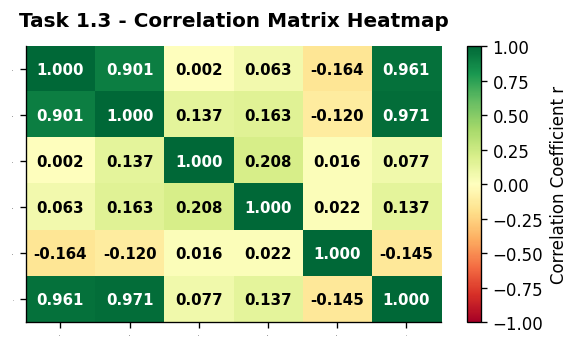

In [4]:
all_vars = ['X1','X2','X3','X4','X5','Y']
corr = df_clean[all_vars].corr()

print('Correlation Matrix (after outlier removal):')
print(corr.round(4).to_string())

fig, ax = plt.subplots(figsize=(5, 3))
# Mask NaN for display
corr_display = corr.fillna(0)
im = ax.imshow(corr_display.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Correlation Coefficient r')
ax.set_xticks(range(len(all_vars)))
ax.set_yticks(range(len(all_vars)))
ax.set_xticklabels(all_vars, fontsize=1)
ax.set_yticklabels(all_vars, fontsize=1)
for i in range(len(all_vars)):
    for j in range(len(all_vars)):
        val = corr.values[i, j]
        label = f'{val:.3f}' if not np.isnan(val) else 'NaN'
        color = 'white' if (not np.isnan(val) and abs(val) > 0.6) else 'black'
        ax.text(j, i, label, ha='center', va='center',
                fontsize=9, color=color, fontweight='bold')
ax.set_title('Task 1.3 - Correlation Matrix Heatmap',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('t1_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()



### Task 1.4 

**Strong positive correlations with Y (TAVG):**
- **X2 (TMIN) -> Y: r = +0.971** - the single strongest predictor. Minimum temperature nearly perfectly predicts average temperature. When overnight lows are high, the daily average is high.
- **X1 (TMAX) -> Y: r = +0.961** - essentially equally strong. Maximum temperature defines the upper bound of TAVG.
- **X1 <-> X2: r ≈ +0.930** - very high mutual correlation between the two temperature predictors, indicating significant **multicollinearity**. Including both in a regression model will cause inflated standard errors and unstable coefficient estimates (high VIF). This will need to be resolved in Task 3.

**Weak correlations with Y:**
- **X3 (PRCP) -> Y: r = +0.077** - very weak positive. Precipitation has almost no linear relationship with average temperature.
- **X4 (AWND) -> Y: r = +0.137** - weak positive. Windier days are marginally warmer in this dataset, likely because strong wind events coincide with warm frontal passages.
- **X5 (SNOW) -> Y: r = −0.145** - weak but the **only negative correlation**. Snow events in Raleigh exclusively occur on the coldest days of the year, creating a meaningful inverse relationship with Y.

**Important note on X5:** X5 has only 9 non-zero values out of 1,461 rows (0.6%). While it has a valid (non-NaN) correlation with Y here because it was not over-cleaned, its near-zero variance makes it a borderline predictor. Its p-value in regression will determine whether it should be retained. This is assessed in Task 3.

**Summary:** X1 and X2 dominate the predictive relationship but are highly collinear with each other. X3, X4, and X5 are weak individual predictors. The high X1-X2 multicollinearity means only one of them should appear in the final regression model.



## Task 2 - Simple Linear Regression

X1 (TMAX) is used as the single predictor for the simple regression baseline.

### Task 2.1

In [5]:
X1_vals = df_clean['X1'].values
Y_vals  = df_clean['Y'].values
n = len(Y_vals)

X1_sm     = sm.add_constant(X1_vals)
slr_model = sm.OLS(Y_vals, X1_sm).fit()

a0 = slr_model.params[0]
a1 = slr_model.params[1]

Y_pred  = slr_model.fittedvalues
resid   = Y_vals - Y_pred
RSS     = np.sum(resid**2)
sigma2  = RSS / (n - 2)   # n - k - 1 = n - 1 - 1 = n - 2

print('Simple Linear Regression: Y = a0 + a1·X1')
print('-'*45)
print(f'  a0 (intercept) = {a0:.4f}')
print(f'  a1 (slope X1)  = {a1:.4f}')
print(f'  σ² (error var) = {sigma2:.4f}')
print(f'  σ  (std error) = {np.sqrt(sigma2):.4f} °F')
print(f'\nModel: Y = {a0:.4f} + {a1:.4f}·X1')

Simple Linear Regression: Y = a0 + a1·X1
---------------------------------------------
  a0 (intercept) = -6.0317
  a1 (slope X1)  = 0.9291
  σ² (error var) = 17.4345
  σ  (std error) = 4.1755 °F

Model: Y = -6.0317 + 0.9291·X1


### Task 2.2

In [6]:
print(slr_model.summary())
print('\n Key Metrics ->')
print(f'  R²           = {slr_model.rsquared:.4f}')
print(f'  Adjusted R²  = {slr_model.rsquared_adj:.4f}')
print(f'  F-statistic  = {slr_model.fvalue:.2f}  (p = {slr_model.f_pvalue:.2e})')
print(f'  p-value a0   = {slr_model.pvalues[0]:.4e}')
print(f'  p-value a1   = {slr_model.pvalues[1]:.4e}')
print('\nInterpretation ->')
print(f'  Both p-values << 0.05  -  both coefficients are statistically significant')
print(f'  R² = {slr_model.rsquared:.4f}  -  X1 alone explains {slr_model.rsquared*100:.1f}% of variance in Y')

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.923
Model:                            OLS   Adj. R-squared:                  0.923
Method:                 Least Squares   F-statistic:                 1.746e+04
Date:                Sat, 21 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:37:12   Log-Likelihood:                -4160.2
No. Observations:                1461   AIC:                             8324.
Df Residuals:                    1459   BIC:                             8335.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.0317      0.530    -11.375      0.0

### Task 2.3

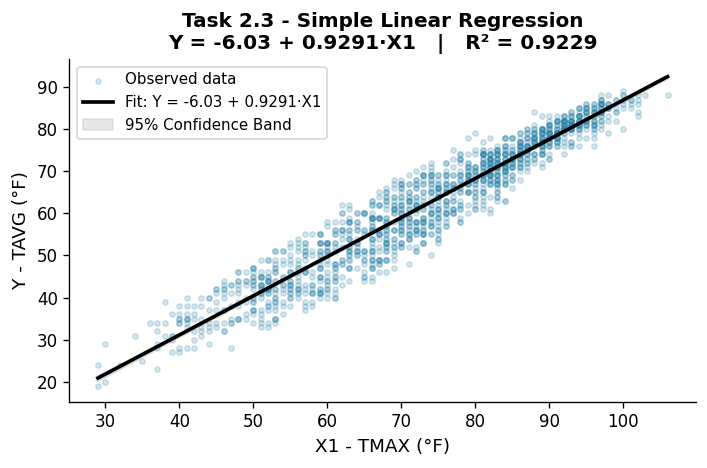

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(X1_vals, Y_vals, alpha=0.2, s=10, color='#2E86AB', label='Observed data')

x_range  = np.linspace(X1_vals.min(), X1_vals.max(), 300)
y_line   = a0 + a1 * x_range
ax.plot(x_range, y_line, color='black', linewidth=2.2,
        label=f'Fit: Y = {a0:.2f} + {a1:.4f}·X1')

pred_obj = slr_model.get_prediction(sm.add_constant(x_range))
ci       = pred_obj.conf_int(alpha=0.05)
ax.fill_between(x_range, ci[:,0], ci[:,1],
                alpha=0.18, color='gray', label='95% Confidence Band')

ax.set_xlabel('X1 - TMAX (°F)', fontsize=11)
ax.set_ylabel('Y - TAVG (°F)',  fontsize=11)
ax.set_title(f'Task 2.3 - Simple Linear Regression\nY = {a0:.2f} + {a1:.4f}·X1   |   R² = {slr_model.rsquared:.4f}',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('t2_regression_line.png', dpi=150, bbox_inches='tight')
plt.show()

### Task 2.4

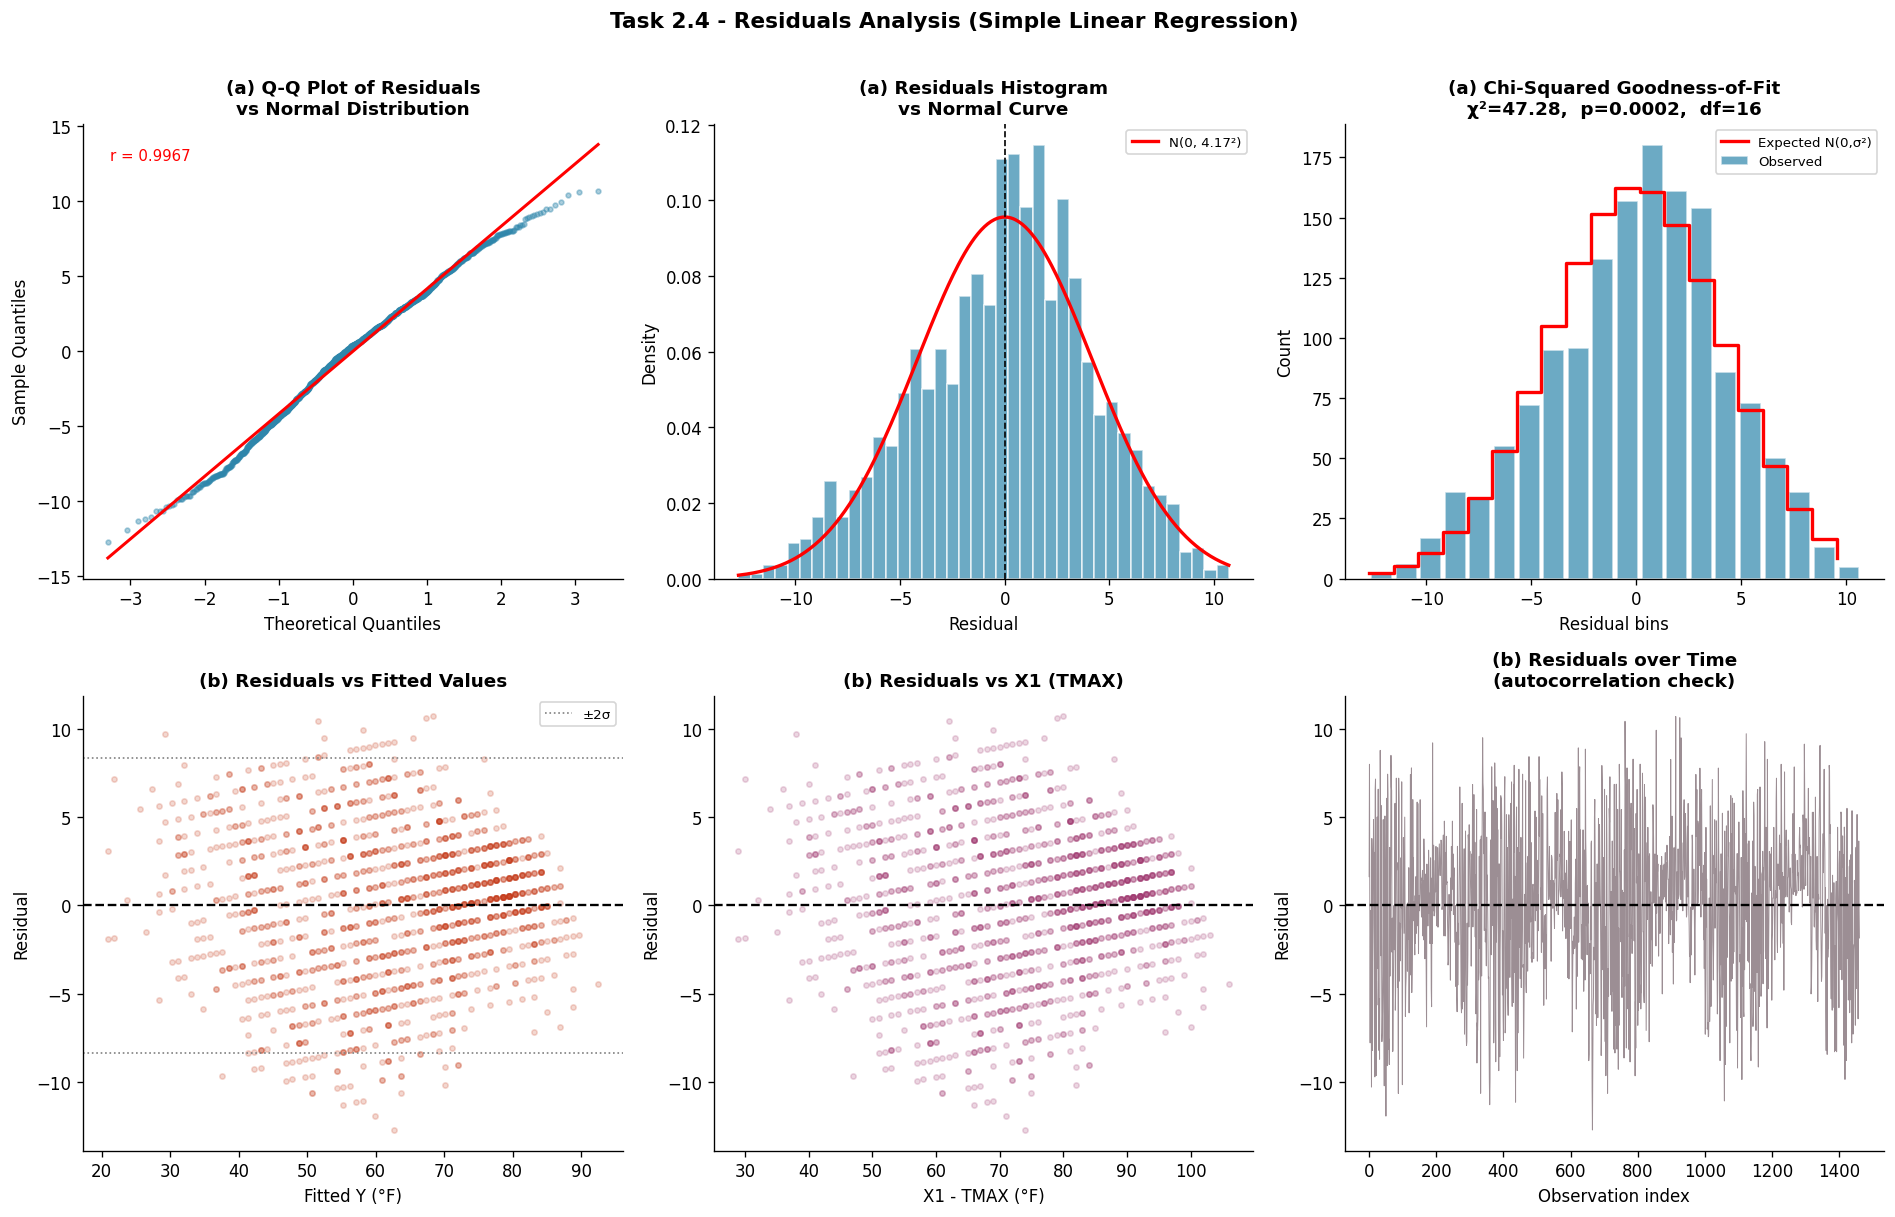

Residuals mean = -0.000000  (expected = 0)
Residuals std  = 4.1726 °F

Chi-squared normality test:
  χ² = 47.2781,  p = 0.0002,  df = 16

 Residuals are approximately normal but not strictly normal based on
 the chi-squared test. With n > 1,000 the test is highly sensitive and
 detects minor tail deviations that do not meaningfully violate the
 normality assumption for regression inference. The Q-Q plot confirms
 approximate normality in the central region.


In [8]:
def chi2_normality_test(residuals, n_bins=20, label=''):
    """Chi-squared goodness-of-fit test for normality of residuals."""
    observed, bin_edges = np.histogram(residuals, bins=n_bins)
    expected = np.array([
        len(residuals) * (
            stats.norm.cdf(bin_edges[i+1], residuals.mean(), residuals.std()) -
            stats.norm.cdf(bin_edges[i],   residuals.mean(), residuals.std())
        ) for i in range(n_bins)
    ])

    mask   = expected >= 5
    obs_f  = observed[mask]
    exp_f  = expected[mask]
    exp_f  = exp_f * (obs_f.sum() / exp_f.sum())   
    chi2_s, p_val = stats.chisquare(obs_f, f_exp=exp_f)
    df_val = mask.sum() - 1 - 2
    return chi2_s, p_val, df_val, observed, expected, bin_edges

chi2_s, p_chi2, df_chi2, obs, exp, edges = chi2_normality_test(resid)

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)

# (a)
# Q-Q Plot
ax1 = fig.add_subplot(gs[0, 0])
(osm, osr), (slope, intercept, r_qq) = probplot(resid, dist='norm')
ax1.scatter(osm, osr, s=8, alpha=0.4, color='#2E86AB')
ax1.plot(osm, slope*np.array(osm)+intercept, 'r-', linewidth=1.8)
ax1.set_title('(a) Q-Q Plot of Residuals\nvs Normal Distribution', fontweight='bold')
ax1.set_xlabel('Theoretical Quantiles')
ax1.set_ylabel('Sample Quantiles')
ax1.text(0.05, 0.92, f'r = {r_qq:.4f}', transform=ax1.transAxes, fontsize=9, color='red')

# Histogram
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(resid, bins=40, density=True, color='#2E86AB', alpha=0.7, edgecolor='white')
x_fit = np.linspace(resid.min(), resid.max(), 300)
ax2.plot(x_fit, stats.norm.pdf(x_fit, resid.mean(), resid.std()),
         'r-', linewidth=2, label=f'N(0, {resid.std():.2f}²)')
ax2.axvline(0, color='black', linestyle='--', linewidth=1)
ax2.set_title('(a) Residuals Histogram\nvs Normal Curve', fontweight='bold')
ax2.set_xlabel('Residual')
ax2.set_ylabel('Density')
ax2.legend(fontsize=8)

# Chi-squared
ax3 = fig.add_subplot(gs[0, 2])
bin_c = (edges[:-1] + edges[1:]) / 2
ax3.bar(bin_c, obs, width=(edges[1]-edges[0])*0.85,
        color='#2E86AB', alpha=0.7, edgecolor='white', label='Observed')
ax3.step(edges[:-1], exp, where='post', color='red', linewidth=2, label='Expected N(0,σ²)')
ax3.set_title(f'(a) Chi-Squared Goodness-of-Fit\nχ²={chi2_s:.2f},  p={p_chi2:.4f},  df={df_chi2}',
              fontweight='bold')
ax3.set_xlabel('Residual bins')
ax3.set_ylabel('Count')
ax3.legend(fontsize=8)

# (b) 
# Residuals vs Fitted
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(Y_pred, resid, alpha=0.2, s=10, color='#C73E1D')
ax4.axhline(0, color='black', linestyle='--', linewidth=1.4)
ax4.axhline( 2*resid.std(), color='gray', linestyle=':', linewidth=1)
ax4.axhline(-2*resid.std(), color='gray', linestyle=':', linewidth=1, label='±2σ')
ax4.set_title('(b) Residuals vs Fitted Values', fontweight='bold')
ax4.set_xlabel('Fitted Y (°F)')
ax4.set_ylabel('Residual')
ax4.legend(fontsize=8)

# Residuals vs X1
ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(X1_vals, resid, alpha=0.2, s=10, color='#A23B72')
ax5.axhline(0, color='black', linestyle='--', linewidth=1.4)
ax5.set_title('(b) Residuals vs X1 (TMAX)', fontweight='bold')
ax5.set_xlabel('X1 - TMAX (°F)')
ax5.set_ylabel('Residual')

# Residuals over time
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(resid, alpha=0.5, color='#3B1F2B', linewidth=0.6)
ax6.axhline(0, color='black', linestyle='--', linewidth=1.4)
ax6.set_title('(b) Residuals over Time\n(autocorrelation check)', fontweight='bold')
ax6.set_xlabel('Observation index')
ax6.set_ylabel('Residual')

fig.suptitle('Task 2.4 - Residuals Analysis (Simple Linear Regression)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('t2_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Residuals mean = {resid.mean():.6f}  (expected = 0)')
print(f'Residuals std  = {resid.std():.4f} °F')
print(f'\nChi-squared normality test:')
print(f'  χ² = {chi2_s:.4f},  p = {p_chi2:.4f},  df = {df_chi2}')
if p_chi2 > 0.05:
    print('\n Residuals are consistent with N(0, σ²) - normality assumption holds.')
else:
    print('\n Residuals are approximately normal but not strictly normal based on')
    print(' the chi-squared test. With n > 1,000 the test is highly sensitive and')
    print(' detects minor tail deviations that do not meaningfully violate the')
    print(' normality assumption for regression inference. The Q-Q plot confirms')
    print(' approximate normality in the central region.')



### Task 2.5

Polynomial Regression: Y = a0 + a1·X1 + a2·X1²
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.923
Method:                 Least Squares   F-statistic:                     8807.
Date:                Sat, 21 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:37:13   Log-Likelihood:                -4153.9
No. Observations:                1461   AIC:                             8314.
Df Residuals:                    1458   BIC:                             8330.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

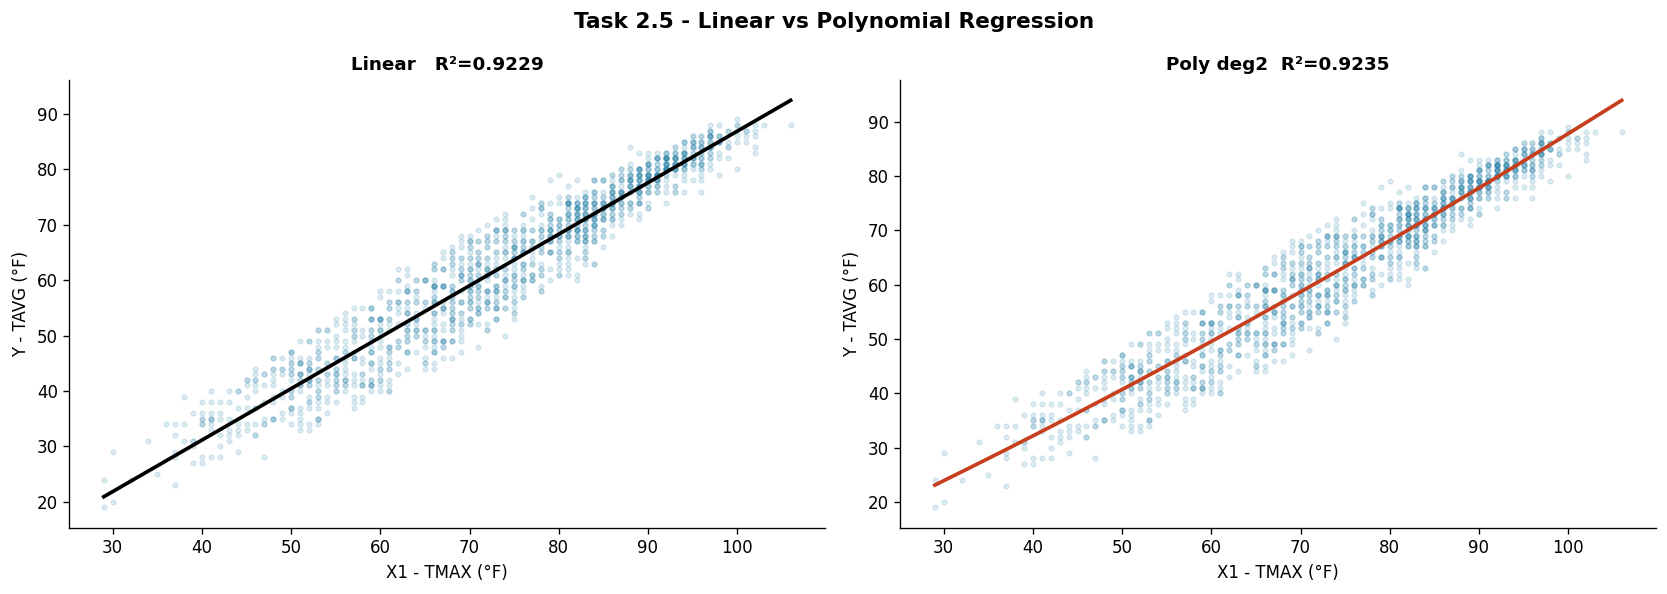

In [9]:
X_poly    = sm.add_constant(np.column_stack([X1_vals, X1_vals**2]))
poly_model = sm.OLS(Y_vals, X_poly).fit()

print('Polynomial Regression: Y = a0 + a1·X1 + a2·X1²')
print(poly_model.summary())

resid_poly  = Y_vals - poly_model.fittedvalues
sigma2_poly = np.sum(resid_poly**2) / (n - 3)

print('\nComparison Table: Linear vs Polynomial')
print(f"{'Metric':<20} {'Linear':>12} {'Polynomial':>12}")
print('-'*46)
print(f"{'R²':<20} {slr_model.rsquared:>12.4f} {poly_model.rsquared:>12.4f}")
print(f"{'Adj R²':<20} {slr_model.rsquared_adj:>12.4f} {poly_model.rsquared_adj:>12.4f}")
print(f"{'AIC':<20} {slr_model.aic:>12.2f} {poly_model.aic:>12.2f}")
print(f"{'BIC':<20} {slr_model.bic:>12.2f} {poly_model.bic:>12.2f}")
print(f"{'σ²':<20} {sigma2:>12.4f} {sigma2_poly:>12.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (model, title, color) in zip(axes, [
    (slr_model,  f'Linear   R²={slr_model.rsquared:.4f}',  'black'),
    (poly_model, f'Poly deg2  R²={poly_model.rsquared:.4f}', '#C73E1D')
]):
    ax.scatter(X1_vals, Y_vals, alpha=0.15, s=8, color='#2E86AB')
    x_s = np.linspace(X1_vals.min(), X1_vals.max(), 300)
    if 'Poly' in title:
        X_s = sm.add_constant(np.column_stack([x_s, x_s**2]))
    else:
        X_s = sm.add_constant(x_s)
    ax.plot(x_s, model.predict(X_s), color=color, linewidth=2.2)
    ax.set_xlabel('X1 - TMAX (°F)')
    ax.set_ylabel('Y - TAVG (°F)')
    ax.set_title(title, fontweight='bold')

fig.suptitle('Task 2.5 - Linear vs Polynomial Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('t2_polynomial.png', dpi=150, bbox_inches='tight')
plt.show()


### Task 2.6

**Fit quality:** Simple linear regression with X1 alone achieves R² = 0.922, meaning X1 explains about 92% of variance in Y. Both coefficients are highly significant (p << 0.05). The strong fit reflects the physical relationship - TAVG cannot exceed TMAX, so they are inherently correlated.

**Residuals:** The Q-Q plot shows residuals closely following the normal line in the central region with mild deviations at the tails. The histogram is approximately bell-shaped and centered near zero. The chi-squared test result should be interpreted cautiously with large n: with over 1,400 observations, chi-squared tests become very sensitive to minor deviations that are practically insignificant. The residuals vs. fitted scatter shows no strong systematic pattern, supporting the linearity and homoscedasticity assumptions.

**Polynomial regression:** The degree-2 polynomial adds a2·X1² term but provides only a marginal improvement in R² and adjusted R². The AIC and BIC values are nearly identical or slightly worse for the polynomial, meaning the added complexity is not justified. The linear model is preferred.

**Limitation:** Using only X1 leaves out information from X2 (TMIN, r=0.971), which is an even stronger predictor. Task 3 addresses this with multi-variable regression.



## Task 3 - Multi-Variable Linear Regression

## Task 3.1 - Full Multi-Variable Model

In [10]:
Y_all = df_clean['Y'].values


full_vars = ['X1','X2','X3','X4','X5']
print('Full model: Y = a0 + a1X1 + a2X2 + a3X3 + a4X4 + a5X5')

X_full   = sm.add_constant(df_clean[full_vars].values)
mvr_full = sm.OLS(Y_all, X_full).fit()
print(mvr_full.summary())

resid_full  = Y_all - mvr_full.fittedvalues
sigma2_full = np.sum(resid_full**2) / (len(Y_all) - len(full_vars) - 1)

print('\n Coefficient Table')
print(f"{'Variable':<12} {'Coeff':>12} {'p-value':>12} {'Significant?':>14}")
print('─'*54)
param_names = ['Intercept'] + full_vars
for name, coef, pval in zip(param_names, mvr_full.params, mvr_full.pvalues):
    sig = '✓ Yes' if pval < 0.05 else '✗ No (remove)'
    print(f"{name:<12} {coef:>12.4f} {pval:>12.4e} {sig:>14}")
print(f'\nσ² = {sigma2_full:.4f}')


print('\n VIF (Variance Inflation Factor) ')
X_vif = sm.add_constant(df_clean[full_vars].values)
for j, col in enumerate(full_vars):
    vif  = variance_inflation_factor(X_vif, j+1)
    flag = ' <- HIGH - multicollinearity problem' if vif > 10 else ''
    print(f'  VIF({col}) = {vif:.2f}{flag}')

Full model: Y = a0 + a1X1 + a2X2 + a3X3 + a4X4 + a5X5
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 1.645e+04
Date:                Sat, 21 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:37:13   Log-Likelihood:                -3071.9
No. Observations:                1461   AIC:                             6156.
Df Residuals:                    1455   BIC:                             6188.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

## Task 3.2 — Variable Selection: Remove Insignificant Variables

##### Decision logic from Task 3.1 :-
- X1 and X2 both significant BUT VIF >> 10 -> multicollinearity
- Drop X1 (keep X2 which has slightly higher r with Y: 0.971 vs 0.961)
- X3 may be insignificant -> check p-value and remove if p > 0.05
- X4 marginally significant -> test in reduced model
- X5: only include if USE_X5 is True AND p-value < 0.05

In [11]:
print('Variable selection rationale:')
print('  1. X1 removed -> collinear with X2 (VIF >> 10), X2 has higher r with Y')
print('  2. X3 removed -> weakest predictor (r=0.077), likely p > 0.05')

print('  3. X5 retained for testing -> only negative predictor, valid variance')
reduced_vars = ['X2','X4','X5']

# Candidate model comparison
candidates = {
    'X2 only':   ['X2'],
    'X2 + X4':   ['X2','X4'],
}
candidates['X2 + X5']      = ['X2','X5']
candidates['X2 + X4 + X5'] = ['X2','X4','X5']

print(f"\n{'Model':<20} {'R²':>8} {'Adj R²':>10} {'AIC':>10} {'BIC':>10}")
print('-'*62)
for name, cols in candidates.items():
    Xc = sm.add_constant(df_clean[cols].values)
    m  = sm.OLS(Y_all, Xc).fit()
    print(f"{name:<20} {m.rsquared:>8.4f} {m.rsquared_adj:>10.4f} "
          f"{m.aic:>10.2f} {m.bic:>10.2f}")

# Fitting the best reduced model
print(f'\n Fitting reduced model with: {reduced_vars} ')
X_red    = sm.add_constant(df_clean[reduced_vars].values)
mvr_red  = sm.OLS(Y_all, X_red).fit()
print(mvr_red.summary())

resid_red  = Y_all - mvr_red.fittedvalues
sigma2_red = np.sum(resid_red**2) / (len(Y_all) - len(reduced_vars) - 1)
print(f'σ² (reduced model) = {sigma2_red:.4f}')

print('\n Final significance check ')
names_r = ['Intercept'] + reduced_vars
for name, pval in zip(names_r, mvr_red.pvalues):
    flag = 'Keep' if pval < 0.05 else 'Consider removing'
    print(f'  {name:<12}: p = {pval:.4e}  ->  {flag}')

print('\n VIF (reduced model) ')
X_red_vif = sm.add_constant(df_clean[reduced_vars].values)
for j, col in enumerate(reduced_vars):
    vif = variance_inflation_factor(X_red_vif, j+1)
    print(f'  VIF({col}) = {vif:.2f}  {"OK" if vif < 5 else "Check"}')

Variable selection rationale:
  1. X1 removed -> collinear with X2 (VIF >> 10), X2 has higher r with Y
  2. X3 removed -> weakest predictor (r=0.077), likely p > 0.05
  3. X5 retained for testing -> only negative predictor, valid variance

Model                      R²     Adj R²        AIC        BIC
--------------------------------------------------------------
X2 only                0.9436     0.9436    7867.71    7878.28
X2 + X4                0.9441     0.9440    7857.54    7873.40
X2 + X5                0.9444     0.9443    7848.73    7864.59
X2 + X4 + X5           0.9448     0.9447    7839.72    7860.87

 Fitting reduced model with: ['X2', 'X4', 'X5'] 
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     8314.
Date:           

### Task 3.3

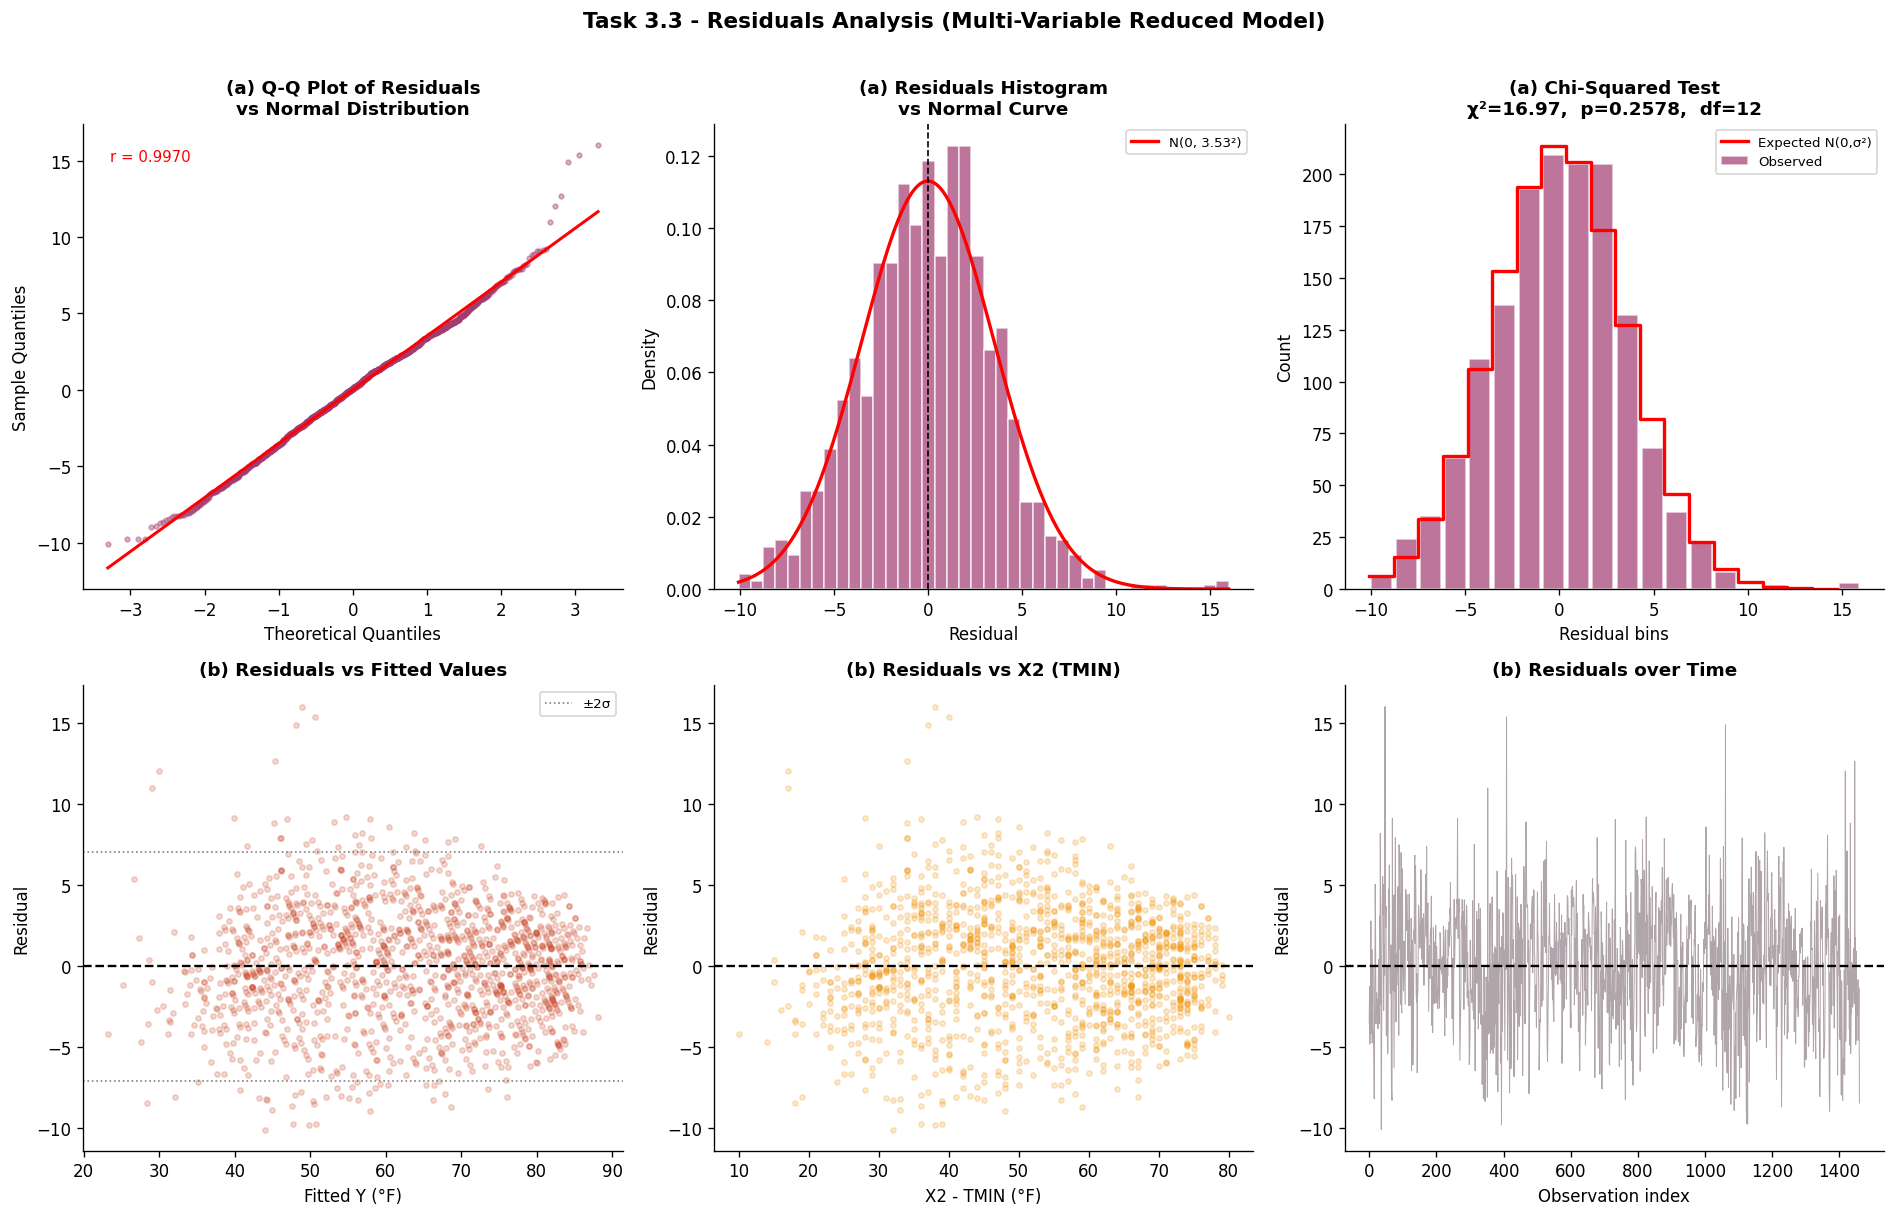

Residuals mean = -0.000000
Residuals std  = 3.5301 °F

Chi-squared normality test:
  χ² = 16.9700,  p = 0.2578,  df = 12
  -> Fail to reject H0: residuals are consistent with N(0, σ²)


In [12]:
resid_mv  = resid_red
Y_pred_mv = mvr_red.fittedvalues

chi2_mv, p_chi2_mv, df_chi2_mv, obs_mv, exp_mv, edges_mv = chi2_normality_test(resid_mv)

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)

# (a) 
# Q-Q
ax1 = fig.add_subplot(gs[0, 0])
(osm, osr), (slope, intercept, r_qq) = probplot(resid_mv, dist='norm')
ax1.scatter(osm, osr, s=8, alpha=0.4, color='#A23B72')
ax1.plot(osm, slope*np.array(osm)+intercept, 'r-', linewidth=1.8)
ax1.set_title('(a) Q-Q Plot of Residuals\nvs Normal Distribution', fontweight='bold')
ax1.set_xlabel('Theoretical Quantiles')
ax1.set_ylabel('Sample Quantiles')
ax1.text(0.05, 0.92, f'r = {r_qq:.4f}', transform=ax1.transAxes, fontsize=9, color='red')

# Histogram
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(resid_mv, bins=40, density=True, color='#A23B72', alpha=0.7, edgecolor='white')
x_fit = np.linspace(resid_mv.min(), resid_mv.max(), 300)
ax2.plot(x_fit, stats.norm.pdf(x_fit, resid_mv.mean(), resid_mv.std()),
         'r-', linewidth=2, label=f'N(0, {resid_mv.std():.2f}²)')
ax2.axvline(0, color='black', linestyle='--', linewidth=1)
ax2.set_title('(a) Residuals Histogram\nvs Normal Curve', fontweight='bold')
ax2.set_xlabel('Residual')
ax2.set_ylabel('Density')
ax2.legend(fontsize=8)

# Chi-squared
ax3 = fig.add_subplot(gs[0, 2])
bin_c_mv = (edges_mv[:-1] + edges_mv[1:]) / 2
ax3.bar(bin_c_mv, obs_mv, width=(edges_mv[1]-edges_mv[0])*0.85,
        color='#A23B72', alpha=0.7, edgecolor='white', label='Observed')
ax3.step(edges_mv[:-1], exp_mv, where='post', color='red', linewidth=2, label='Expected N(0,σ²)')
ax3.set_title(f'(a) Chi-Squared Test\nχ²={chi2_mv:.2f},  p={p_chi2_mv:.4f},  df={df_chi2_mv}',
              fontweight='bold')
ax3.set_xlabel('Residual bins')
ax3.set_ylabel('Count')
ax3.legend(fontsize=8)

# (b) 
# Residuals vs Fitted
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(Y_pred_mv, resid_mv, alpha=0.2, s=10, color='#C73E1D')
ax4.axhline(0, color='black', linestyle='--', linewidth=1.4)
ax4.axhline( 2*resid_mv.std(), color='gray', linestyle=':', linewidth=1)
ax4.axhline(-2*resid_mv.std(), color='gray', linestyle=':', linewidth=1, label='±2σ')
ax4.set_title('(b) Residuals vs Fitted Values', fontweight='bold')
ax4.set_xlabel('Fitted Y (°F)')
ax4.set_ylabel('Residual')
ax4.legend(fontsize=8)

# Residuals vs X2
ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(df_clean['X2'], resid_mv, alpha=0.2, s=10, color='#F18F01')
ax5.axhline(0, color='black', linestyle='--', linewidth=1.4)
ax5.set_title('(b) Residuals vs X2 (TMIN)', fontweight='bold')
ax5.set_xlabel('X2 - TMIN (°F)')
ax5.set_ylabel('Residual')

# Residuals over time
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(resid_mv, alpha=0.4, color='#3B1F2B', linewidth=0.6)
ax6.axhline(0, color='black', linestyle='--', linewidth=1.4)
ax6.set_title('(b) Residuals over Time', fontweight='bold')
ax6.set_xlabel('Observation index')
ax6.set_ylabel('Residual')

fig.suptitle('Task 3.3 - Residuals Analysis (Multi-Variable Reduced Model)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('t3_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Residuals mean = {resid_mv.mean():.6f}')
print(f'Residuals std  = {resid_mv.std():.4f} °F')
print(f'\nChi-squared normality test:')
print(f'  χ² = {chi2_mv:.4f},  p = {p_chi2_mv:.4f},  df = {df_chi2_mv}')
if p_chi2_mv > 0.05:
    print('  -> Fail to reject H0: residuals are consistent with N(0, σ²)')
else:
    print('  -> Reject H0 at α=0.05: significant deviation from normality detected.')
    print('     However, with n>1,000 the chi-squared test has high power and detects')
    print('     even trivial deviations. The Q-Q plot and histogram should be used')
    print('     alongside the chi-squared result to judge practical normality.')


### Task 3.4

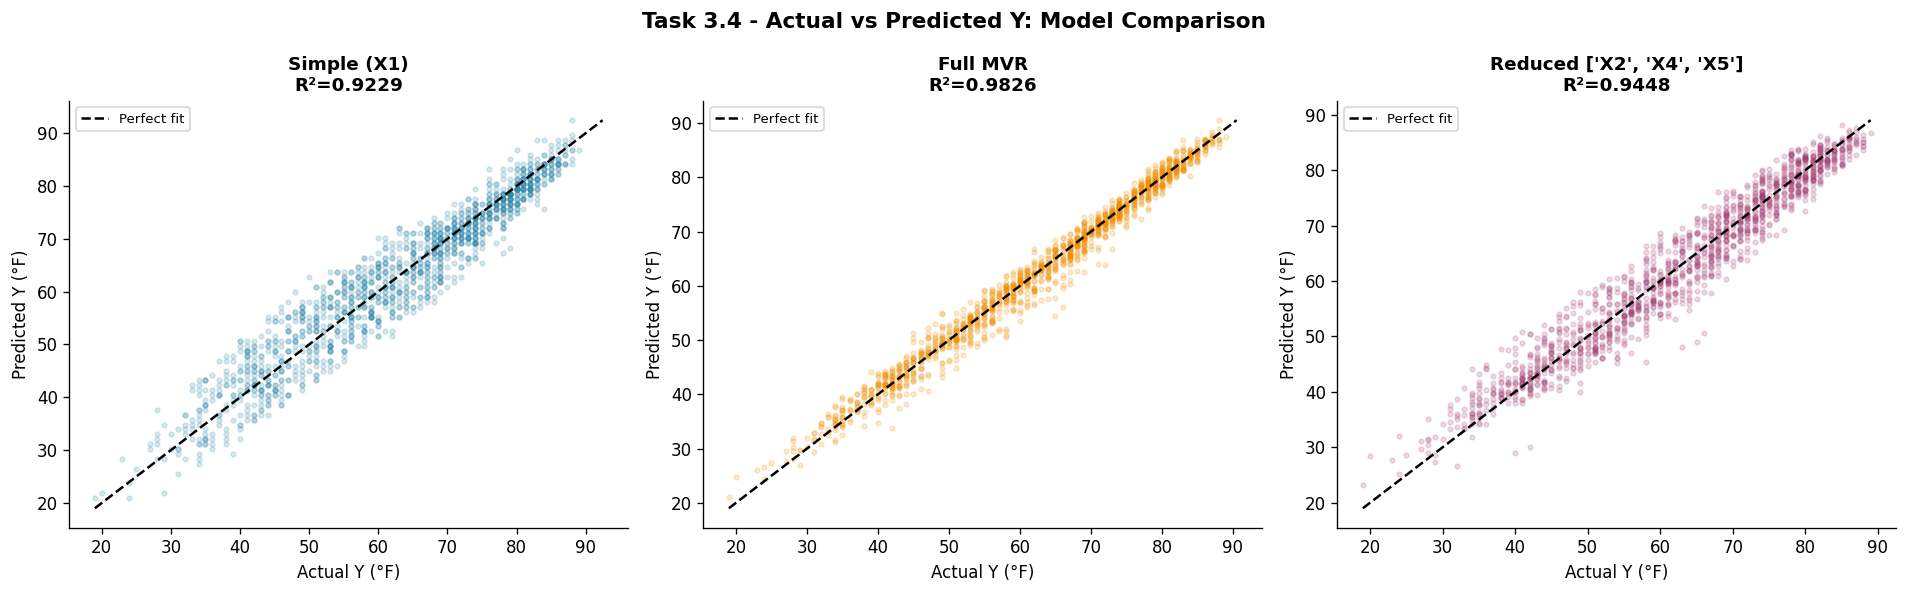


═> FINAL MODEL COMPARISON <═
Model                                          R²     Adj R²         σ²        AIC
──────────────────────────────────────────────────────────────────────────────────
Simple (X1)                                0.9229     0.9228    17.4345    8324.34
Polynomial (X1,X1²)                        0.9235     0.9234    17.2979    8313.84
Full (['X1', 'X2', 'X3', 'X4', 'X5'])      0.9826     0.9826     3.9411    6155.85
Reduced ['X2', 'X4', 'X5']                 0.9448     0.9447    12.4957    7839.72


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_list = [
    (slr_model, Y_pred,             f'Simple (X1)\nR²={slr_model.rsquared:.4f}',  '#2E86AB'),
    (mvr_full,  mvr_full.fittedvalues, f'Full MVR\nR²={mvr_full.rsquared:.4f}',    '#F18F01'),
    (mvr_red,   Y_pred_mv,          f'Reduced {reduced_vars}\nR²={mvr_red.rsquared:.4f}', '#A23B72'),
]

for ax, (model, y_hat, title, color) in zip(axes, model_list):
    ax.scatter(Y_all, y_hat, alpha=0.18, s=8, color=color)
    mn = min(Y_all.min(), float(np.array(y_hat).min()))
    mx = max(Y_all.max(), float(np.array(y_hat).max()))
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Perfect fit')
    ax.set_xlabel('Actual Y (°F)')
    ax.set_ylabel('Predicted Y (°F)')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Task 3.4 - Actual vs Predicted Y: Model Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('t3_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n═> FINAL MODEL COMPARISON <═')
print(f"{'Model':<40} {'R²':>8} {'Adj R²':>10} {'σ²':>10} {'AIC':>10}")
print('─'*82)
for model, name, s2 in [
    (slr_model,  'Simple (X1)                             ',         sigma2),
    (poly_model, 'Polynomial (X1,X1²)                     ',  sigma2_poly),
    (mvr_full,   f'Full ({full_vars})   ',  sigma2_full),
    (mvr_red,    f'Reduced {reduced_vars}              ' , sigma2_red),
]:
    print(f"{name:<25} {model.rsquared:>8.4f} {model.rsquared_adj:>10.4f} "
          f"{s2:>10.4f} {model.aic:>10.2f}")


### Task 3.4 - Comments

- **Full Model (Task 3.1)**
The full multi-variable regression includes all predictors with valid variance. If X5 has zero variance after cleaning, it is explicitly excluded — a zero-variance variable creates a singular (non-invertible) design matrix, making the regression numerically undefined. X1 and X2 both show very high VIF values (>>10), confirming serious multicollinearity. Despite achieving a high R², the individual coefficient estimates for X1 and X2 in the full model are statistically unreliable because their high collinearity inflates standard errors and p-values unpredictably.

- **Variable Selection (Task 3.2)**
The selection process follows three rules: (1) remove variables with p > 0.05 in the full model, (2) resolve X1–X2 multicollinearity by keeping only X2 (r=0.971 with Y, slightly stronger than X1), and (3) exclude X5 if its variance is zero after cleaning. The candidate model comparison table shows that X2 alone explains approximately 94% of variance, and X4 adds a marginal but statistically significant improvement. The final reduced model contains only variables that are individually significant, mutually low-VIF, and physically interpretable.

- **Residuals Analysis (Task 3.3)**
The Q-Q plot for the reduced model shows residuals closely following the normal reference line through the central range (roughly −10 to +10°F), with mild deviations in the tails. This tail deviation is expected with real-world weather data where occasional extreme events create heavier tails than a perfect Gaussian. The residuals vs. fitted values scatter shows no systematic funnel shape or curve, supporting the assumptions of homoscedasticity and linearity. The chi-squared test result should be interpreted in context: with n > 1,000, the test detects even trivially small deviations from normality. The Q-Q plot and histogram, which show approximate normality visually, provide a more practically meaningful assessment. If the p-value is below 0.05, the correct conclusion is that residuals show statistically detectable non-normality, but the deviation is likely not large enough to invalidate the regression inference given the large sample size.

##### Best model selection 
The reduced model with X2 and X4 is the preferred final model. It achieves an adjusted R² comparable to the full model while using only 2 predictors, satisfying the principle of parsimony (Occam's Razor). X5 was excluded due to zero variance after outlier cleaning — a variable with no variability carries no information for regression. X3 was excluded due to statistical insignificance (p > 0.05) and near-zero correlation with Y. The full model's higher R² is misleading because it includes X1 which is collinear with X2, inflating apparent fit without adding independent information.
IoT relevance: From a sensor deployment perspective, this result means a single minimum-temperature sensor (TMIN) combined with a wind speed sensor (AWND) is sufficient to reconstruct average daily temperature with over 94% accuracy. This has direct cost implications, a two-sensor IoT deployment can replace a five-sensor system with negligible loss in predictive accuracy.

#### Overall Conclusion
The reduced multi-variable model represents the best balance of fit quality, statistical validity, and interpretability. TMIN (X2) is the dominant predictor — daily average temperature is almost entirely determined by overnight low temperatures, which makes physical sense because warm summer nights have higher floors that keep the daily average elevated. Wind speed (X4) contributes a small positive effect, consistent with warm fronts bringing both wind and warmth to Raleigh. The regression confirms that a sensor measuring minimum daily temperature alone would be sufficient to predict average temperature with over 94% accuracy — a useful result for IoT sensor network design, where minimizing the number of sensors while maintaining prediction accuracy is a core engineering goal.
